In [ ]:
# 1️⃣ Montar Google Drive primero
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =============================================================
# 🧩 Entorno Colab estable (sin Drive, compatible con GPU L4)
# =============================================================

# 1️⃣ Eliminar versiones problemáticas (NumPy 2.x, OpenCV 4.12)
!pip uninstall -y numpy opencv-python opencv-python-headless -q

# 2️⃣ Instalar versiones estables y compatibles entre sí
!pip install numpy==1.26.4 opencv-python==4.8.1.78 opencv-python-headless==4.8.1.78 --no-cache-dir -q
!pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 albumentations==1.4.8 pycocotools==2.0.7 tqdm --no-cache-dir -q

# 3️⃣ Importar librerías y verificar compatibilidad
import numpy as np, torch, torchvision, cv2
print("✅ NumPy:", np.__version__)
print("✅ Torch:", torch.__version__, "| Torchvision:", torchvision.__version__)
print("✅ OpenCV:", cv2.__version__)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("🚀 Dispositivo:", DEVICE)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 138.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 257.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 MB 340.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 MB 257.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
albucore 0.0.24 requires opencv-python-headless>=4.9.0.80, but you have opencv-python-headless 4.8.1.78 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
albumentations 2.0.8 requires opencv-python-headless>=4.9.0.80, but you have opencv-python-headless 4.8.1.78 which is incompatib

In [ ]:
# =============================================================
# 🔧 Ajuste final para compatibilidad con NumPy 2.x (Colab 2025)
# =============================================================

!pip install --upgrade --no-cache-dir pycocotools==2.0.10 albumentations==1.4.8 tqdm --quiet
!pip install --upgrade --force-reinstall --no-cache-dir opencv-python==4.12.0.88 torch torchvision torchaudio --quiet

import numpy as np, torch, torchvision, cv2
print("✅ NumPy:", np.__version__)
print("✅ Torch:", torch.__version__, "| Torchvision:", torchvision.__version__)
print("✅ OpenCV:", cv2.__version__)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("🚀 Dispositivo:", DEVICE)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.1/397.1 kB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 348.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 270.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 125.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 159.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 162.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 201.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 135.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 375.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 228.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 110.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 400.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import warnings
warnings.filterwarnings("ignore")


In [ ]:
# ========= RUTAS: SUBFRAMES + JSON COCO =========
# Accuracy (TP/(TP+FP+FN)) : 0.4300
# F1-micro: 0.6014 | F1-macro: 0.4855
# MAE (conteo por imagen)  : 2.468
# RMSE (conteo por imagen) : 3.923
# Ajusta estas rutas si tus carpetas tienen otro nombre
SUB_IMG_DIR_TRAIN = "/content/drive/MyDrive/general_dataset/train_subframes"
SUB_IMG_DIR_VAL = "/content/drive/MyDrive/general_dataset/val_subframes_gen"
# SUB_IMG_DIR_VAL   = "/content/drive/MyDrive/general_dataset/val_subframes"
# SUB_IMG_DIR_TEST  = "/content/drive/MyDrive/general_dataset/test_subframes"

SUB_JSON_TRAIN = "/content/drive/MyDrive/general_dataset/groundtruth/json/sub_frames/train_subframes_A_B_E_K_WH_WB.json"
SUB_JSON_VAL = "/content/drive/MyDrive/general_dataset/groundtruth/json/sub_frames/val_subframes_A_B_E_K_WH_WB.json"
# SUB_JSON_VAL   = "/content/drive/MyDrive/general_dataset/groundtruth/json/sub_frames/val_subframes_A_B_E_K_WH_WB.json"
# SUB_JSON_TEST  = "/content/drive/MyDrive/general_dataset/groundtruth/json/sub_frames/test_subframes_A_B_E_K_WH_WB.json"

# Carpeta de modelos
MODEL_DIR = "/content/drive/MyDrive/general_dataset/models"
import os
os.makedirs(MODEL_DIR, exist_ok=True)

# =============================================================
# 🚀 ENTRENAMIENTO FASTER R-CNN (SUBFRAMES COCO)
# =============================================================
import torch, torchvision, json, time
from torch.utils.data import DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
from matplotlib import pyplot as plt
from tqdm import tqdm
import numpy as np
from PIL import Image

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("🔥 Entrenando en:", DEVICE)

# ---------- utilidades ----------
def _to_xyxy_clipped(bbox, W, H):
    """COCO bbox [x,y,w,h] → [x1,y1,x2,y2] y recorta a límites de imagen."""
    x, y, w, h = bbox
    x1 = max(0.0, x)
    y1 = max(0.0, y)
    x2 = min(float(W), x + max(0.0, w))
    y2 = min(float(H), y + max(0.0, h))
    # proteger contra cajas degeneradas
    if x2 <= x1: x2 = min(float(W), x1 + 1.0)
    if y2 <= y1: y2 = min(float(H), y1 + 1.0)
    return [x1, y1, x2, y2]

def _get_num_classes_from_json(path_json):
    with open(path_json, "r", encoding="utf-8") as f:
        data = json.load(f)
    cats = data.get("categories", [])
    if not cats:
        raise ValueError(f"No se encontraron 'categories' en {path_json}")
    cat_ids = sorted({int(c.get("id", 0)) for c in cats})
    # torchvision espera num_classes = num_categorias + 1 (background)
    return len(cat_ids) + 1

# ---------- Dataset adaptado ----------
class CocoSubframes(CocoDetection):
    """
    Lee imágenes subframe y anotaciones COCO.
    Devuelve:
      img: Tensor CxHxW
      target: dict(boxes[N,4], labels[N], image_id[int])
    """
    def __getitem__(self, idx):
        img, anns = super().__getitem__(idx)

        # tamaño imagen
        W, H = img.size
        img = F.to_tensor(img)  # [0,1]

        boxes, labels = [], []
        if isinstance(anns, list):
            for a in anns:
                if "bbox" not in a or "category_id" not in a:
                    continue
                boxes.append(_to_xyxy_clipped(a["bbox"], W, H))
                labels.append(int(a["category_id"]))

        if len(boxes) == 0:
            # imagen sin anotaciones: cajas vacías (evita errores en collate)
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx], dtype=torch.int64)
        }
        return img, target

# ---------- Carga de datasets ----------
# Si no tienes val/test, puedes poner SUB_JSON_VAL = SUB_JSON_TRAIN y SUB_IMG_DIR_VAL = SUB_IMG_DIR_TRAIN
train_ds = CocoSubframes(SUB_IMG_DIR_TRAIN, SUB_JSON_TRAIN)
val_ds   = CocoSubframes(SUB_IMG_DIR_VAL,   SUB_JSON_VAL)

def collate_fn(batch):
    return tuple(zip(*batch))

train_dl = DataLoader(train_ds, batch_size=2, shuffle=True,
                      num_workers=2, collate_fn=collate_fn, pin_memory=True)
val_dl   = DataLoader(val_ds, batch_size=2, shuffle=False,
                      num_workers=2, collate_fn=collate_fn, pin_memory=True)

# ---------- Modelo ----------
num_classes = _get_num_classes_from_json(SUB_JSON_TRAIN)
print(f"🔢 num_classes (incluye background): {num_classes}")

model = fasterrcnn_resnet50_fpn_v2(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)
model.to(DEVICE)

# ---------- Optimizador y scheduler ----------
opt = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=10)

# ---------- Entrenamiento ----------
def train_one_epoch(epoch):
    model.train()
    total_loss = 0.0
    start = time.time()
    for imgs, tgts in tqdm(train_dl, desc=f"Epoch {epoch:02d}"):
        imgs = [im.to(DEVICE) for im in imgs]
        tgts = [{k: v.to(DEVICE) for k, v in t.items()} for t in tgts]

        losses_dict = model(imgs, tgts)  # dict con losses
        loss = sum(losses_dict.values())

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        opt.step()

        total_loss += float(loss.item())

    dur = (time.time() - start) / 60.0
    avg_loss = total_loss / max(1, len(train_dl))
    print(f"🕒 Duración época: {dur:.1f} min | Pérdida promedio: {avg_loss:.4f}")
    return avg_loss

@torch.no_grad()
def evaluate_val(score_thr=0.5):
    """
    Métrica rápida: MAE del conteo de cajas por imagen (pred vs. gt),
    usando umbral de score para filtrar predicciones.
    """
    model.eval()
    maes = []
    for imgs, tgts in val_dl:
        imgs = [im.to(DEVICE) for im in imgs]
        outs = model(imgs)
        for pred, t in zip(outs, tgts):
            pred_n = (pred.get("scores", torch.tensor([])) > score_thr).sum().item()
            true_n = int(t["boxes"].shape[0])
            maes.append(abs(pred_n - true_n))
    return float(np.mean(maes)) if len(maes) else np.nan

# ---------- Reanudar desde checkpoint si existe ----------
last_ckpt = None
for f in sorted(os.listdir(MODEL_DIR)):
    if f.startswith("checkpoint_subframes_epoch_"):
        last_ckpt = os.path.join(MODEL_DIR, f)

if last_ckpt:
    print(f"🔄 Reanudando desde: {last_ckpt}")
    model.load_state_dict(torch.load(last_ckpt, map_location=DEVICE))

# ---------- Loop de entrenamiento con guardado intermedio ----------
EPOCHS = 10
for ep in range(1, EPOCHS + 1):
    loss = train_one_epoch(ep)
    mae  = evaluate_val(score_thr=0.5)
    sched.step()
    print(f"[Epoch {ep:02d}] loss={loss:.4f} | MAE={mae:.3f}")

    if ep % 2 == 0:
        ckpt_path = f"{MODEL_DIR}/checkpoint_subframes_epoch_{ep:02d}.pth"
        torch.save(model.state_dict(), ckpt_path)
        print(f"💾 Guardado {ckpt_path}")

# ---------- Guardar modelo final ----------
final_path = f"{MODEL_DIR}/fasterrcnn_animals_subframes.pth"
torch.save(model.state_dict(), final_path)
print(f"✅ Modelo final guardado en {final_path}")


🔥 Entrenando en: cuda
loading annotations into memory...
Done (t=2.96s)
creating index...
index created!
loading annotations into memory...
Done (t=0.95s)
creating index...
index created!
🔢 num_classes (incluye background): 7


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth
100%|██████████| 167M/167M [00:00<00:00, 241MB/s]


🔄 Reanudando desde: /content/drive/MyDrive/general_dataset/models/checkpoint_subframes_epoch_10.pth


Epoch 01: 100%|██████████| 862/862 [13:52<00:00,  1.04it/s]

🕒 Duración época: 13.9 min | Pérdida promedio: 0.2134


...

🕒 Duración época: 1.8 min | Pérdida promedio: 0.0746


[Epoch 09] loss=0.0746 | MAE=0.607


Epoch 10: 100%|██████████| 862/862 [01:39<00:00,  8.66it/s]

🕒 Duración época: 1.7 min | Pérdida promedio: 0.0674


[Epoch 10] loss=0.0674 | MAE=0.616
💾 Guardado /content/drive/MyDrive/general_dataset/models/checkpoint_subframes_epoch_10.pth
✅ Modelo final guardado en /content/drive/MyDrive/general_dataset/models/fasterrcnn_animals_subframes.pth


In [ ]:
#Antes del siguiente entrenamiento se deben ajustar compatibilidad de versiones
!pip install -U "numpy>=2.1" "scipy>=1.11" \
  "opencv-python-headless>=4.10.0.84" \
  "albumentations>=1.4.7" \
  "scikit-image>=0.24.0" \
  "pycocotools>=2.0.8" \
  "pillow>=10.3" \
  "torch>=2.4" "torchvision>=0.19"

#Al terminar reiniciar entorno de ejecucion/reiniciar sesion

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 369.4/369.4 kB 38.9 MB/s eta 0:00:00
  Attempting uninstall: albumentations
    Found existing installation: albumentations 1.4.7
    Uninstalling albumentations-1.4.7:
      Successfully uninstalled albumentations-1.4.7


In [ ]:
#Validamos versiones
import numpy, torch, torchvision, albumentations, cv2, PIL
print("numpy:", numpy.__version__)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("albumentations:", albumentations.__version__)
print("opencv:", cv2.__version__)
print("Pillow:", PIL.__version__)


numpy: 2.2.6
torch: 2.9.0+cu128
torchvision: 0.24.0+cu128
albumentations: 2.0.8
opencv: 4.12.0
Pillow: 12.0.0


In [ ]:
# ============================================================
# Entrenamiento v2 - Faster R-CNN (Subframes COCO)
# - Albumentations + Oversampling + Anchors/RPN + SGD+Warmup
# ============================================================

# 0) Drive
from google.colab import drive
drive.mount('/content/drive')

# 1) RUTAS
SUB_IMG_DIR_TRAIN = "/content/drive/MyDrive/general_dataset/train_subframes"
SUB_IMG_DIR_VAL   = "/content/drive/MyDrive/general_dataset/val_subframes_gen"   # si no tienes, usa train
SUB_JSON_TRAIN    = "/content/drive/MyDrive/general_dataset/groundtruth/json/sub_frames/train_subframes_A_B_E_K_WH_WB.json"
SUB_JSON_VAL      = "/content/drive/MyDrive/general_dataset/groundtruth/json/sub_frames/val_subframes_A_B_E_K_WH_WB.json"

MODEL_DIR         = "/content/drive/MyDrive/general_dataset/models_v2"

# 2) Instalación Albumentations (si no está)
!pip -q install albumentations==1.4.7 --no-warn-conflicts

# 3) Imports
import os, json, math, time, numpy as np
from pathlib import Path
from collections import Counter, defaultdict

import torch, torchvision
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.anchor_utils import AnchorGenerator

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
from PIL import Image

os.makedirs(MODEL_DIR, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("🔥 Dispositivo:", DEVICE)

# 4) Utilidades
def _to_xyxy_clipped(bbox, W, H):
    x, y, w, h = bbox
    x1 = max(0.0, x); y1 = max(0.0, y)
    x2 = min(float(W), x + max(0.0, w))
    y2 = min(float(H), y + max(0.0, h))
    if x2 <= x1: x2 = min(float(W), x1 + 1.0)
    if y2 <= y1: y2 = min(float(H), y1 + 1.0)
    return [x1, y1, x2, y2]

def get_num_classes_from_json(path_json):
    with open(path_json, "r", encoding="utf-8") as f:
        data = json.load(f)
    cat_ids = sorted({int(c["id"]) for c in data["categories"]})
    return len(cat_ids) + 1, {int(c["id"]): c["name"] for c in data["categories"]}

# 5) Albumentations (fuerte, con bbox COCO y labels)
import cv2
PAD_VALUE = (0, 0, 0)  # color de relleno para bordes/acolchado (RGB)

def build_augs(train=True):
    if train:
        return A.Compose([
            A.OneOf([
                A.RandomBrightnessContrast(0.2, 0.2, p=1.0),
                A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=1.0),
                A.RandomGamma(gamma_limit=(85,115), p=1.0),
            ], p=0.9),
            A.HueSaturationValue(5, 10, 5, p=0.5),
            A.OneOf([A.MotionBlur(3, p=1.0), A.GaussianBlur(3, p=1.0)], p=0.2),
            A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
            A.RandomShadow(num_shadows_lower=1, num_shadows_upper=2, p=0.15),
            A.ShiftScaleRotate(shift_limit=0.02, scale_limit=0.12, rotate_limit=10,
                               border_mode=cv2.BORDER_CONSTANT, value=PAD_VALUE, p=0.7),
            A.LongestMaxSize(max_size=1536, p=1.0),
            A.PadIfNeeded(min_height=1024, min_width=1024,
                          border_mode=cv2.BORDER_CONSTANT, value=PAD_VALUE, p=1.0),
            A.ToFloat(max_value=255.0),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='coco', min_visibility=0.4, label_fields=['category_id']))
    else:
        return A.Compose([
            A.LongestMaxSize(max_size=1536, p=1.0),
            A.PadIfNeeded(min_height=1024, min_width=1024,
                          border_mode=cv2.BORDER_CONSTANT, value=PAD_VALUE, p=1.0),
            A.ToFloat(max_value=255.0),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='coco', min_visibility=0.0, label_fields=['category_id']))

# 6) Dataset con Albumentations (NO pasar transforms al padre)
class CocoSubframesAugs(CocoDetection):
    def __init__(self, img_folder, ann_file, augment=None):
        super().__init__(img_folder, ann_file, transforms=None)
        self.augment = augment or build_augs(train=True)

    def __getitem__(self, idx):
        img, anns = super().__getitem__(idx)
        img_np = np.array(img)

        bboxes, labels = [], []
        if isinstance(anns, list):
            for a in anns:
                if "bbox" in a and "category_id" in a:
                    bboxes.append(a["bbox"])
                    labels.append(int(a["category_id"]))

        aug = self.augment(image=img_np, bboxes=bboxes, category_id=labels)
        img_t = aug["image"]           # tensor (esperado) CxHxW
        b_aug = aug["bboxes"]; l_aug = aug["category_id"]

        # ✅ Blindaje de tipo/rango
        if not isinstance(img_t, torch.Tensor):
            img_t = torch.from_numpy(img_t)
        if img_t.dtype != torch.float32:
            img_t = img_t.float()
        if img_t.max() > 1.0:
            img_t = img_t / 255.0

        if len(b_aug) == 0:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
        else:
            H, W = img_t.shape[1], img_t.shape[2]
            boxes_xyxy = [_to_xyxy_clipped(b, W, H) for b in b_aug]
            boxes = torch.as_tensor(boxes_xyxy, dtype=torch.float32)
            labels_t = torch.as_tensor(l_aug, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels_t,
            "image_id": torch.tensor([idx], dtype=torch.int64)
        }
        return img_t, target


def collate_fn(batch):
    return tuple(zip(*batch))

# 7) Datasets / Dataloaders con Oversampling
num_classes, id2name = get_num_classes_from_json(SUB_JSON_TRAIN)
name2id = {v:k for k,v in id2name.items()}
print(f"🔢 num_classes (incl. fondo) = {num_classes}")

train_ds = CocoSubframesAugs(SUB_IMG_DIR_TRAIN, SUB_JSON_TRAIN, augment=build_augs(train=True))
val_ds   = CocoSubframesAugs(SUB_IMG_DIR_VAL,   SUB_JSON_VAL,   augment=build_augs(train=False))

# Oversampling por imagen si contiene clases minoritarias
minor_names = ["Warthog", "Waterbuck"]  # ajustable
minor_ids = {name2id[n] for n in minor_names if n in name2id}
weights = np.ones(len(train_ds), dtype=np.float32)

for i, img_id in enumerate(train_ds.ids):
    ann_ids = train_ds.coco.getAnnIds(imgIds=[img_id])
    anns = train_ds.coco.loadAnns(ann_ids)
    if any(a["category_id"] in minor_ids for a in anns):
        weights[i] *= 3.0  # triplica prob. de muestreo

sampler = WeightedRandomSampler(weights, num_samples=len(train_ds), replacement=True)

# Ajustes automáticos según GPU
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
else:
    gpu_name = "CPU"
if "A100" in gpu_name:
    BATCH_SIZE, NUM_WORKERS = 6, 4
elif "L4" in gpu_name:
    BATCH_SIZE, NUM_WORKERS = 4, 4
elif "T4" in gpu_name:
    BATCH_SIZE, NUM_WORKERS = 2, 2
else:
    BATCH_SIZE, NUM_WORKERS = 1, 0

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                      collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)
val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                      collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)

print(f"⚙️ batch_size={BATCH_SIZE}, workers={NUM_WORKERS}")

# 8) Modelo con Anchors personalizados + RPN reforzado
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.models.detection.rpn import RPNHead

# --- Modelo base ---
model = fasterrcnn_resnet50_fpn_v2(weights="DEFAULT")

# --- Anchors personalizados (5 niveles del FPN) ---
# Importante: MISMO número de escalas en cada nivel (p.ej., 2 en todos)
sizes = (
    (8, 16),       # P3
    (32, 64),      # P4
    (128, 256),    # P5
    (256, 512),    # P6
    (512, 1024)    # P7
)
aspect_ratios = ((0.5, 1.0, 2.0),) * 5

anchor_gen = AnchorGenerator(sizes=sizes, aspect_ratios=aspect_ratios)
model.rpn.anchor_generator = anchor_gen  # ← aplicar después de crear el modelo

# (CRÍTICO) Reconstruir cabeza del RPN acorde al #anchors por celda
num_anchors_per_level = anchor_gen.num_anchors_per_location()  # e.g., [6,6,6,6,6]
assert len(set(num_anchors_per_level)) == 1, "Todos los niveles deben tener el mismo # de anchors por celda"
num_anchors = num_anchors_per_level[0]

out_channels = model.backbone.out_channels  # canales de salida del FPN
model.rpn.head = RPNHead(out_channels, num_anchors)

# RPN: más propuestas para subir recall (opcional)
model.rpn.pre_nms_top_n_train  = 4000
model.rpn.pre_nms_top_n_test   = 2000
model.rpn.post_nms_top_n_train = 2000
model.rpn.post_nms_top_n_test  = 1000
model.rpn.nms_thresh = 0.7

# --- Ajustar el predictor de clases ---
in_feats = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_feats, num_classes
)

# (Opcional) Sanity checks
print("Anchors por nivel:", num_anchors_per_level)  # debería ser [6,6,6,6,6]

model.to(DEVICE)

# 9) Optimizador, Warmup y Scheduler
opt = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=1e-4)

# warmup: primeras 1000 iteraciones a lr más bajo
def lr_lambda(step):
    warmup_iters = 1000
    if step < warmup_iters:
        return float(step) / float(max(1, warmup_iters))
    return 1.0
warmup = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lr_lambda)

# luego MultiStep
main_sched = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[8, 11], gamma=0.1)

# 10) Métricas val (conteo/IoU simplificado, F1-macro)
@torch.no_grad()
def evaluate_val(model, score_thr=0.5, iou_thr=0.5, max_batches=None):
    model.eval()
    from collections import Counter
    tp = Counter(); fp = Counter(); fn = Counter()

    seen_batches = 0
    for imgs, tgts in val_dl:
        imgs = [im.to(DEVICE) for im in imgs]
        outs = model(imgs)
        for o, t in zip(outs, tgts):
            keep = (o["scores"].detach().cpu() >= score_thr).numpy()
            p_boxes = o["boxes"].detach().cpu().numpy()[keep]
            p_labels = o["labels"].detach().cpu().numpy()[keep]

            g_boxes = t["boxes"].numpy()
            g_labels = t["labels"].numpy()

            # greedy IoU match
            def iou(a, b):
                ax1, ay1, ax2, ay2 = a; bx1, by1, bx2, by2 = b
                ix1, iy1 = max(ax1,bx1), max(ay1,by1)
                ix2, iy2 = min(ax2,bx2), min(ay2,by2)
                iw, ih = max(0, ix2-ix1), max(0, iy2-iy1)
                inter = iw*ih
                if inter<=0: return 0.0
                ua = (ax2-ax1)*(ay2-ay1) + (bx2-bx1)*(by2-by1) - inter
                return inter / max(ua, 1e-9)

            used_g, used_p = set(), set()
            cand = []
            for gi, gb in enumerate(g_boxes):
                for pi, pb in enumerate(p_boxes):
                    i = iou(gb, pb)
                    if i >= iou_thr:
                        cand.append((gi, pi, i))
            cand.sort(key=lambda x: x[2], reverse=True)
            for gi, pi, i in cand:
                if gi in used_g or pi in used_p:
                    continue
                used_g.add(gi); used_p.add(pi)
                if g_labels[gi] == p_labels[pi]:
                    tp[g_labels[gi]] += 1
                else:
                    fn[g_labels[gi]] += 1
                    fp[p_labels[pi]] += 1

            for gi in range(len(g_boxes)):
                if gi not in used_g:
                    fn[g_labels[gi]] += 1
            for pi in range(len(p_boxes)):
                if pi not in used_p:
                    fp[p_labels[pi]] += 1

        seen_batches += 1
        if max_batches and seen_batches >= max_batches:
            break

    # F1 macro
    f1s = []
    for cid in sorted(id2name.keys()):
        tpi, fpi, fni = tp[cid], fp[cid], fn[cid]
        prec = tpi / max(tpi+fpi, 1)
        rec  = tpi / max(tpi+fni, 1)
        f1   = 0.0 if (prec+rec)==0 else 2*prec*rec/(prec+rec)
        f1s.append(f1)
    f1_macro = float(np.mean(f1s)) if f1s else 0.0
    return f1_macro

# 11) Entrenamiento
EPOCHS = 12
best_f1 = -1.0
global_step = 0

def train_one_epoch(epoch):
    global global_step
    model.train()
    running = 0.0
    pbar = tqdm(train_dl, desc=f"Epoch {epoch:02d}")
    for imgs, tgts in pbar:
        imgs = [im.to(DEVICE) for im in imgs]
        tgts = [{k: v.to(DEVICE) for k, v in t.items()} for t in tgts]
        loss_dict = model(imgs, tgts)
        loss = sum(loss_dict.values())

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
        opt.step()

        # warmup (primeras 1000 iters)
        if global_step < 1000:
            warmup.step()
        running += float(loss.item())
        global_step += 1
        pbar.set_postfix(loss=f"{running/(pbar.n or 1):.4f}")
    return running / max(len(train_dl), 1)

for ep in range(1, EPOCHS+1):
    avg_loss = train_one_epoch(ep)
    f1_val = evaluate_val(model, score_thr=0.5, iou_thr=0.5)
    main_sched.step()
    print(f"[Epoch {ep:02d}] loss={avg_loss:.4f} | F1-macro(val)={f1_val:.4f}")

    # checkpoint periódico
    if ep % 2 == 0:
        ckpt = f"{MODEL_DIR}/checkpoint_ep{ep:02d}.pth"
        torch.save(model.state_dict(), ckpt)
        print(f"💾 Guardado {ckpt}")

    # mejor por F1-macro
    if f1_val > best_f1:
        best_f1 = f1_val
        best_path = f"{MODEL_DIR}/best_f1_macro.pth"
        torch.save(model.state_dict(), best_path)
        print(f"🏆 Nuevo mejor (F1-macro={best_f1:.4f}) → {best_path}")

final_path = f"{MODEL_DIR}/fasterrcnn_animals_subframes_v2.pth"
torch.save(model.state_dict(), final_path)
print(f"✅ Modelo final: {final_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔥 Dispositivo: cuda
🔢 num_classes (incl. fondo) = 7
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...


/tmp/ipython-input-807195658.py:86: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
/tmp/ipython-input-807195658.py:87: UserWarning: Argument(s) 'num_shadows_lower, num_shadows_upper' are not valid for transform RandomShadow
  A.RandomShadow(num_shadows_lower=1, num_shadows_upper=2, p=0.15),
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
/tmp/ipython-input-807195658.py:88: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.02, scale_limit=0.12, rotate_limit=10,
/tmp/ipython-input-807195658.py:91: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=1024, min_width=1024,
/tmp/ipython-input-807195658.py:99: UserWarning: Argument(s) 'value' are not valid for transform PadIf

Done (t=0.73s)
creating index...
index created!
⚙️ batch_size=6, workers=4
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 242MB/s]


Anchors por nivel: [6, 6, 6, 6, 6]


...

[Epoch 10] loss=0.1911 | F1-macro(val)=0.4288
💾 Guardado /content/drive/MyDrive/general_dataset/models_v2/checkpoint_ep10.pth
🏆 Nuevo mejor (F1-macro=0.4288) → /content/drive/MyDrive/general_dataset/models_v2/best_f1_macro.pth


Epoch 11: 100%|██████████| 288/288 [01:40<00:00,  2.88it/s, loss=0.1992]


[Epoch 11] loss=0.1985 | F1-macro(val)=0.4162


Epoch 12: 100%|██████████| 288/288 [01:29<00:00,  3.21it/s, loss=0.1953]


[Epoch 12] loss=0.1947 | F1-macro(val)=0.4118
💾 Guardado /content/drive/MyDrive/general_dataset/models_v2/checkpoint_ep12.pth
✅ Modelo final: /content/drive/MyDrive/general_dataset/models_v2/fasterrcnn_animals_subframes_v2.pth


In [ ]:
# =========================
# 🔎 Inferencia en TEST v2
# Métricas: F1 (por clase y macro), MAE, RMSE, AC, Matriz de Confusión
# =========================
import os, json, math, numpy as np
from collections import Counter, defaultdict
from pathlib import Path

import torch, torchvision
from torch.utils.data import DataLoader
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.models.detection.rpn import RPNHead

import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import cv2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("🔥 Dispositivo:", DEVICE)

# -------------------------
# Rutas
# -------------------------
TEST_IMG_DIR  = "/content/drive/MyDrive/general_dataset/test_subframes_gen"
TEST_JSON_RAW = "/content/drive/MyDrive/general_dataset/groundtruth/json/sub_frames/test_subframes_A_B_E_K_WH_WB.json"
MODEL_DIR     = "/content/drive/MyDrive/general_dataset/models_v2"
CKPT_PATH     = f"{MODEL_DIR}/best_f1_macro.pth"  # ajusta si quieres el final/fijo

# Si el JSON termina en .jso y no existe, intenta .json
TEST_JSON = TEST_JSON_RAW
if not os.path.exists(TEST_JSON):
    if TEST_JSON_RAW.endswith(".jso") and os.path.exists(TEST_JSON_RAW + "n"):
        TEST_JSON = TEST_JSON_RAW + "n"
print("→ JSON test usado:", TEST_JSON)

# -------------------------
# Utilidades
# -------------------------
PAD_VALUE = (0,0,0)

def build_augs_eval():
    # mismas augs “suaves” para valid/test que en tu entrenamiento
    return A.Compose([
        A.LongestMaxSize(max_size=1536, p=1.0),
        A.PadIfNeeded(min_height=1024, min_width=1024,
                      border_mode=cv2.BORDER_CONSTANT, value=PAD_VALUE, p=1.0),
        A.ToFloat(max_value=255.0),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='coco', min_visibility=0.0, label_fields=['category_id']))

def _to_xyxy_clipped(bbox, W, H):
    x, y, w, h = bbox
    x1 = max(0.0, x); y1 = max(0.0, y)
    x2 = min(float(W), x + max(0.0, w))
    y2 = min(float(H), y + max(0.0, h))
    if x2 <= x1: x2 = min(float(W), x1 + 1.0)
    if y2 <= y1: y2 = min(float(H), y1 + 1.0)
    return [x1, y1, x2, y2]

def get_num_classes_from_json(path_json):
    with open(path_json, "r", encoding="utf-8") as f:
        data = json.load(f)
    cat_ids = sorted({int(c["id"]) for c in data["categories"]})
    id2name = {int(c["id"]): c["name"] for c in data["categories"]}
    return len(cat_ids) + 1, id2name

class CocoSubframesEval(CocoDetection):
    def __init__(self, img_folder, ann_file, augment=None):
        super().__init__(img_folder, ann_file, transforms=None)
        self.augment = augment or build_augs_eval()

    def __getitem__(self, idx):
        img, anns = super().__getitem__(idx)
        img_np = np.array(img)

        bboxes, labels = [], []
        if isinstance(anns, list):
            for a in anns:
                if "bbox" in a and "category_id" in a:
                    bboxes.append(a["bbox"])
                    labels.append(int(a["category_id"]))

        aug = self.augment(image=img_np, bboxes=bboxes, category_id=labels)
        img_t = aug["image"]
        b_aug = aug["bboxes"]; l_aug = aug["category_id"]

        if not isinstance(img_t, torch.Tensor):
            img_t = torch.from_numpy(img_t)
        if img_t.dtype != torch.float32:
            img_t = img_t.float()
        if img_t.max() > 1.0:
            img_t = img_t / 255.0

        if len(b_aug) == 0:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
        else:
            H, W = img_t.shape[1], img_t.shape[2]
            boxes_xyxy = [_to_xyxy_clipped(b, W, H) for b in b_aug]
            boxes = torch.as_tensor(boxes_xyxy, dtype=torch.float32)
            labels_t = torch.as_tensor(l_aug, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels_t,
            "image_id": torch.tensor([idx], dtype=torch.int64)
        }
        return img_t, target

def collate_fn(batch):
    return tuple(zip(*batch))

# -------------------------
# Dataset / Loader TEST
# -------------------------
num_classes, id2name = get_num_classes_from_json(TEST_JSON)
name2id = {v:k for k,v in id2name.items()}
cls_ids_sorted = sorted(id2name.keys())
print(f"🔢 num_classes (incl. fondo) = {num_classes}")
print("🪪 id2name:", id2name)

# Ajusta batch según GPU
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
else:
    gpu_name = "CPU"

if "A100" in gpu_name:
    BATCH_SIZE, NUM_WORKERS = 6, 4
elif "L4" in gpu_name:
    BATCH_SIZE, NUM_WORKERS = 4, 4
elif "T4" in gpu_name:
    BATCH_SIZE, NUM_WORKERS = 2, 2
else:
    BATCH_SIZE, NUM_WORKERS = 1, 0

test_ds = CocoSubframesEval(TEST_IMG_DIR, TEST_JSON, augment=build_augs_eval())
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                     collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)

print(f"⚙️ TEST batch_size={BATCH_SIZE}, workers={NUM_WORKERS}")

# -------------------------
# Modelo (anchors y heads como en entrenamiento)
# -------------------------
model = fasterrcnn_resnet50_fpn_v2(weights="DEFAULT")

# Anchors personalizados (mismo esquema que usaste)
sizes = (
    (8, 16),       # P3
    (32, 64),      # P4
    (128, 256),    # P5
    (256, 512),    # P6
    (512, 1024)    # P7
)
aspect_ratios = ((0.5, 1.0, 2.0),) * 5

anchor_gen = AnchorGenerator(sizes=sizes, aspect_ratios=aspect_ratios)
model.rpn.anchor_generator = anchor_gen

# Reconstruir cabeza del RPN coherente
num_anchors_per_level = anchor_gen.num_anchors_per_location()
assert len(set(num_anchors_per_level)) == 1, "Todos los niveles deben tener el mismo # de anchors por celda"
num_anchors = num_anchors_per_level[0]
out_channels = model.backbone.out_channels
model.rpn.head = RPNHead(out_channels, num_anchors)

# Ajustar predictor de clases
in_feats = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_feats, num_classes
)

model.to(DEVICE)

# Cargar pesos
assert os.path.exists(CKPT_PATH), f"No se encuentra el checkpoint: {CKPT_PATH}"
state = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(state, strict=True)
model.eval()
print("✅ Pesos cargados:", CKPT_PATH)

# -------------------------
# Evaluación en TEST
# -------------------------
import numpy as np

SCORE_THR = 0.5   # umbral global (si luego quieres per-clase, se puede mapear aquí)
IOU_THR   = 0.5

# Confusion matrix entre clases detectadas (KxK), FNs/FPs se reflejan en TP/FP/FN, no en la matriz
K = len(cls_ids_sorted)
cid_to_idx = {cid:i for i,cid in enumerate(cls_ids_sorted)}
conf_mat = np.zeros((K, K), dtype=np.int64)

tp = Counter(); fp = Counter(); fn = Counter()

abs_errs = []
sq_errs  = []
acc_det  = []

@torch.no_grad()
def iou(a, b):
    ax1, ay1, ax2, ay2 = a; bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    if inter <= 0: return 0.0
    ua = (ax2-ax1)*(ay2-ay1) + (bx2-bx1)*(by2-by1) - inter
    return inter / max(ua, 1e-9)

@torch.no_grad()
def eval_test():
    for imgs, tgts in test_dl:
        imgs = [im.to(DEVICE) for im in imgs]
        outs = model(imgs)

        for o, t in zip(outs, tgts):
            # Conteo GT
            g_boxes = t["boxes"].numpy()
            g_labels = t["labels"].numpy()
            g_count = len(g_boxes)

            # Filtra predicciones por score
            scores = o["scores"].detach().cpu().numpy()
            keep = scores >= SCORE_THR
            p_boxes = o["boxes"].detach().cpu().numpy()[keep]
            p_labels= o["labels"].detach().cpu().numpy()[keep]
            p_count = len(p_boxes)

            # Conteo (para MAE/RMSE/AC)
            abs_errs.append(abs(p_count - g_count))
            sq_errs.append((p_count - g_count) ** 2)
            acc_det.append(int(p_count == g_count))

            # Emparejamiento greedy por IoU
            used_g, used_p = set(), set()
            cand = []
            for gi, gb in enumerate(g_boxes):
                for pi, pb in enumerate(p_boxes):
                    ii = iou(gb, pb)
                    if ii >= IOU_THR:
                        cand.append((gi, pi, ii))
            cand.sort(key=lambda x: x[2], reverse=True)

            for gi, pi, _ in cand:
                if gi in used_g or pi in used_p:
                    continue
                used_g.add(gi); used_p.add(pi)
                gt_c = int(g_labels[gi]); pr_c = int(p_labels[pi])
                if gt_c == pr_c:
                    tp[gt_c] += 1
                    # ConfMat: diagonal
                    conf_mat[cid_to_idx[gt_c], cid_to_idx[pr_c]] += 1
                else:
                    fn[gt_c] += 1
                    fp[pr_c] += 1
                    # ConfMat: error de clase GT->PR
                    conf_mat[cid_to_idx[gt_c], cid_to_idx[pr_c]] += 1

            # FNs (no emparejados)
            for gi in range(len(g_boxes)):
                if gi not in used_g:
                    fn[int(g_labels[gi])] += 1

            # FPs (no emparejados)
            for pi in range(len(p_boxes)):
                if pi not in used_p:
                    fp[int(p_labels[pi])] += 1

# Ejecuta evaluación
eval_test()

# -------------------------
# Agrega métricas
# -------------------------
per_class = {}
f1_list = []
for cid in cls_ids_sorted:
    tpi, fpi, fni = tp[cid], fp[cid], fn[cid]
    prec = tpi / max(tpi + fpi, 1)
    rec  = tpi / max(tpi + fni, 1)
    f1   = 0.0 if (prec + rec) == 0 else 2 * prec * rec / (prec + rec)
    per_class[cid] = {
        "name": id2name[cid],
        "tp": int(tpi), "fp": int(fpi), "fn": int(fni),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
    }
    f1_list.append(f1)

f1_macro = float(np.mean(f1_list)) if f1_list else 0.0
mae  = float(np.mean(abs_errs)) if len(abs_errs) else 0.0
rmse = float(np.sqrt(np.mean(sq_errs))) if len(sq_errs) else 0.0
ac   = float(np.mean(acc_det)) if len(acc_det) else 0.0

# -------------------------
# Reporte
# -------------------------
print("\n==================== RESULTADOS TEST ====================")
for cid in cls_ids_sorted:
    m = per_class[cid]
    print(f"{m['name']:<12s}  P={m['precision']:.3f}  R={m['recall']:.3f}  F1={m['f1']:.3f}  | tp={m['tp']} fp={m['fp']} fn={m['fn']}")

print("----------------------------------------------------------")
print(f"⭐ F1-macro: {f1_macro:.4f}")
print(f"📦 MAE conteo: {mae:.3f}")
print(f"📦 RMSE conteo: {rmse:.3f}")
print(f"✅ AC (conteo exacto por imagen): {ac:.4f}")

print("\n🧮 Matriz de confusión (filas=GT, columnas=Pred):")
# Encabezados bonitos
col_names = [id2name[cid] for cid in cls_ids_sorted]
row_names = col_names
# imprime compacto
head = " " * 14 + " ".join([f"{n[:10]:>10s}" for n in col_names])
print(head)
for i, cid_r in enumerate(cls_ids_sorted):
    row = [f"{conf_mat[i,j]:>10d}" for j,_ in enumerate(cls_ids_sorted)]
    print(f"{row_names[i][:12]:>12s}  " + " ".join(row))



🔥 Dispositivo: cuda
→ JSON test usado: /content/drive/MyDrive/general_dataset/groundtruth/json/sub_frames/test_subframes_A_B_E_K_WH_WB.json
🔢 num_classes (incl. fondo) = 7
🪪 id2name: {1: 'Alcelaphinae', 2: 'Buffalo', 3: 'Kob', 4: 'Warthog', 5: 'Waterbuck', 6: 'Elephant'}
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
⚙️ TEST batch_size=6, workers=4


/tmp/ipython-input-3273411059.py:49: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=1024, min_width=1024,


✅ Pesos cargados: /content/drive/MyDrive/general_dataset/models_v2/best_f1_macro.pth

==================== RESULTADOS TEST ====================
Alcelaphinae  P=0.757  R=0.640  F1=0.694  | tp=436 fp=140 fn=245
Buffalo       P=0.604  R=0.483  F1=0.537  | tp=172 fp=113 fn=184
Kob           P=0.772  R=0.849  F1=0.808  | tp=409 fp=121 fn=73
Warthog       P=0.140  R=0.453  F1=0.215  | tp=34 fp=208 fn=41
Waterbuck     P=0.322  R=0.778  F1=0.455  | tp=28 fp=59 fn=8
Elephant      P=0.081  R=0.138  F1=0.102  | tp=96 fp=1090 fn=600
----------------------------------------------------------
⭐ F1-macro: 0.4684
📦 MAE conteo: 0.910
📦 RMSE conteo: 2.186
✅ AC (conteo exacto por imagen): 0.6092

🧮 Matriz de confusión (filas=GT, columnas=Pred):
              Alcelaphin    Buffalo        Kob    Warthog  Waterbuck   Elephant
Alcelaphinae         436         25         45          8         12          0
     Buffalo           3        172          0         39         17         21
         Kob          17

In [ ]:
# ===================================================================
# 🦁 INFERENCIA SOBRE IMAGEN BIG — PRED vs REAL y EXACTITUD OBTENIDA
# ===================================================================

import cv2
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.models.detection.rpn import RPNHead

# ------------------------------------------------------------
# 0. CONFIGURACIÓN GLOBAL
# ------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("🔥 Using device:", DEVICE)

# Rutas en tu Drive
BEST_WEIGHTS = "/content/drive/MyDrive/general_dataset/models_v2/best_f1_macro.pth"
THR_JSON_OUT = "/content/drive/MyDrive/general_dataset/models_v2/best_thresholds_by_class.json"
# Anotaciones reales de test para comparar con las de la inferencia
GT_JSON_BIG  = "/content/drive/MyDrive/general_dataset/groundtruth/json/big_size/test_big_size_A_B_E_K_WH_WB.json"

# Clases (A/B/E/K/WH/WB)
id2name = {
    1: "Alcelaphinae",
    2: "Buffalo",
    3: "Kob",
    4: "Warthog",
    5: "Waterbuck",
    6: "Elephant"
}
num_classes = len(id2name) + 1   # +1 fondo


# ============================================================
# 1. MODELO IGUAL AL DEL ENTRENAMIENTO
# ============================================================
def build_model_for_eval(num_classes):
    sizes = (
        (8, 16),      # P3
        (32, 64),     # P4
        (128, 256),   # P5
        (256, 512),   # P6
        (512, 1024)   # P7
    )
    aspect_ratios = ((0.5, 1.0, 2.0),) * 5

    model = fasterrcnn_resnet50_fpn_v2(weights=None)

    anchor_gen = AnchorGenerator(sizes=sizes, aspect_ratios=aspect_ratios)
    model.rpn.anchor_generator = anchor_gen

    num_anchors = anchor_gen.num_anchors_per_location()[0]
    out_channels = model.backbone.out_channels
    model.rpn.head = RPNHead(out_channels, num_anchors)

    in_feats = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_feats, num_classes
    )
    return model


# ============================================================
# 2. UTILIDADES SUBFRAMES / DIBUJO
# ============================================================
def ensure_horizontal(img):
    """Gira la imagen 90° si es vertical."""
    h, w = img.shape[:2]
    if h > w:
        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
        return img, True
    return img, False


def generate_subframes(img, rows, cols):
    """Corta img en grilla rows x cols."""
    h, w = img.shape[:2]
    sub_h = h // rows
    sub_w = w // cols
    frames, coords = [], []

    for r in range(rows):
        for c in range(cols):
            y1 = r * sub_h
            y2 = (r + 1) * sub_h if r < rows - 1 else h
            x1 = c * sub_w
            x2 = (c + 1) * sub_w if c < cols - 1 else w
            frames.append(img[y1:y2, x1:x2])
            coords.append((r, c, x1, y1, x2, y2))
    return frames, coords


@torch.no_grad()
def infer_subframe(model, frame, thr_by_cls):
    """Inferencia Faster R-CNN en un subframe BGR."""
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    t = torch.from_numpy(rgb / 255.).float().permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    out = model(t)[0]
    boxes = out["boxes"].cpu().numpy()
    scores = out["scores"].cpu().numpy()
    labels = out["labels"].cpu().numpy()

    keep = []
    for s, lab in zip(scores, labels):
        thr = thr_by_cls.get(int(lab), 0.5)
        keep.append(s >= thr)
    keep = np.array(keep, dtype=bool)

    return boxes[keep], labels[keep]


def draw_boxes(img, boxes, labels, id2name):
    COLORS = {
        "Alcelaphinae": (0, 0, 180),
        "Buffalo":      (255, 200, 150),
        "Kob":          (0, 140, 255),
        "Warthog":      (0, 165, 255),
        "Waterbuck":    (128, 0, 255),
        "Elephant":     (50, 220, 50),
    }

    out = img.copy()
    for box, lab in zip(boxes, labels):
        x1, y1, x2, y2 = box.astype(int)
        cname = id2name[int(lab)]
        col = COLORS.get(cname, (0, 255, 0))
        cv2.rectangle(out, (x1, y1), (x2, y2), col, 2)
        cv2.putText(out, cname, (x1, max(y1 - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, col, 2)
    return out


def draw_grid(img, rows, cols):
    """Dibuja la grilla sobre la imagen grande."""
    g = img.copy()
    h, w = g.shape[:2]
    sh = h // rows
    sw = w // cols
    col = (0, 255, 255)

    for r in range(1, rows):
        y = r * sh
        cv2.line(g, (0, y), (w, y), col, 4)
    for c in range(1, cols):
        x = c * sw
        cv2.line(g, (x, 0), (x, h), col, 4)

    return g


# ============================================================
# 3. GT REAL DESDE JSON DE BIG SIZE
# ============================================================
def get_gt_counts_for_image(gt_json_path, filename):
    """
    Devuelve un dict {nombre_clase: conteo} con las anotaciones
    reales de la imagen 'filename' en el JSON big_size.
    """
    with open(gt_json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    img_id = None
    for im in data["images"]:
        if im["file_name"] == filename:
            img_id = im["id"]
            break

    if img_id is None:
        print(f"⚠️ No se encontró GT para {filename} en {gt_json_path}")
        return {}

    cat_id2name = {c["id"]: c["name"] for c in data["categories"]}

    counts = {}
    for ann in data["annotations"]:
        if ann["image_id"] == img_id:
            cname = cat_id2name.get(ann["category_id"], "UNK")
            counts[cname] = counts.get(cname, 0) + 1

    return counts


# ============================================================
# 4. INFERENCIA COMPLETA SOBRE IMAGEN BIG
# ============================================================
def infer_on_big_image(path_img, rows=2, cols=3):
    # ---- Umbrales por clase ----
    try:
        with open(THR_JSON_OUT, "r", encoding="utf-8") as f:
            name2thr = json.load(f)
        thr_by_cls = {cid: float(name2thr[id2name[cid]]) for cid in id2name}
        print("🔎 Umbrales por clase cargados.")
    except Exception as e:
        print("⚠️ No se pudieron cargar umbrales, usando 0.5. Error:", e)
        thr_by_cls = {cid: 0.5 for cid in id2name}

    # ---- Modelo ----
    print("🔄 Cargando modelo...")
    model = build_model_for_eval(num_classes).to(DEVICE)
    model.load_state_dict(torch.load(BEST_WEIGHTS, map_location=DEVICE))
    model.eval()
    print("✅ Modelo listo.")

    # ---- Imagen BIG ----
    big = cv2.imread(path_img)
    if big is None:
        raise FileNotFoundError("❌ No se pudo leer la imagen.")

    fname = os.path.basename(path_img)

    big, rotated = ensure_horizontal(big)
    if rotated:
        print("↩️ Imagen vertical, rotada a horizontal.")

    # ---- Subframes ----
    subframes, coords = generate_subframes(big, rows, cols)
    print(f"🔹 {len(subframes)} subframes generados ({rows}x{cols}).")

    big_grid = draw_grid(big, rows, cols)

    # ---- Inferencia por subframe ----
    total_counts = {}
    per_sub_counts = {}
    subframes_boxed = []

    for i, (frame, coord) in enumerate(zip(subframes, coords), start=1):
        boxes, labels = infer_subframe(model, frame, thr_by_cls)

        local = {}
        for lab in labels:
            cname = id2name[int(lab)]
            total_counts[cname] = total_counts.get(cname, 0) + 1
            local[cname] = local.get(cname, 0) + 1

        sub_name = f"S{i}"
        per_sub_counts[sub_name] = local
        subframes_boxed.append((sub_name, draw_boxes(frame, boxes, labels, id2name)))

    # -------- Imagen grande con grilla --------
    plt.figure(figsize=(10, 7))
    plt.imshow(cv2.cvtColor(big_grid, cv2.COLOR_BGR2RGB))
    plt.title(f"Full: {fname} | grid={rows}x{cols}")
    plt.axis("off")
    plt.show()

    # -------- Subframes --------
    n_sub = len(subframes_boxed)
    cols_vis = min(cols, n_sub)
    rows_vis = int(np.ceil(n_sub / cols_vis))

    plt.figure(figsize=(4 * cols_vis, 4 * rows_vis))
    gs = gridspec.GridSpec(rows_vis, cols_vis)

    for i, (name, img_b) in enumerate(subframes_boxed):
        r = i // cols_vis
        c = i % cols_vis
        ax = plt.subplot(gs[r, c])
        ax.imshow(cv2.cvtColor(img_b, cv2.COLOR_BGR2RGB))
        ax.set_title(name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    # -------- Resumen por subframe --------
    print("\n📌 Resumen de subframes y anotaciones predichas:")
    for k, v in per_sub_counts.items():
        print(f"  {k}: {v}")

    # -------- GT REAL --------
    gt_counts = get_gt_counts_for_image(GT_JSON_BIG, fname)

    # -------- Gráfica combinada PRED vs GT + exactitud --------
    if gt_counts:
        # conjunto de todas las especies que aparecen en GT o en pred
        all_species = sorted(set(list(gt_counts.keys()) + list(total_counts.keys())))

        gt_vals   = [gt_counts.get(sp, 0) for sp in all_species]
        pred_vals = [total_counts.get(sp, 0) for sp in all_species]

        y = np.arange(len(all_species))
        height = 0.35

        plt.figure(figsize=(8, 5))
        plt.barh(y - height/2, gt_vals, height, label="Real (GT)")
        plt.barh(y + height/2, pred_vals, height, label="Predicho")

        plt.yticks(y, all_species)
        plt.xlabel("Conteo")
        plt.title(f"Conteo por especie — GT vs Pred — {fname}")
        plt.legend()

        # etiquetas numéricas
        for i, (g, p) in enumerate(zip(gt_vals, pred_vals)):
            plt.text(g + 0.05, i - height/2, str(g), va="center")
            plt.text(p + 0.05, i + height/2, str(p), va="center")

        plt.tight_layout()
        plt.show()

        # Exactitud global de conteo
        sum_gt = float(sum(gt_vals))
        sum_abs_err = float(sum(abs(p - g) for p, g in zip(pred_vals, gt_vals)))
        if sum_gt > 0:
            acc = max(0.0, 1.0 - sum_abs_err / sum_gt)
            print(f"\n🎯 Exactitud global de conteo: {acc*100:.2f}%")
        else:
            print("\n⚠️ No hay GT para calcular exactitud.")
    else:
        print("\n⚠️ No hay anotaciones GT para esta imagen en el JSON de big size.")

    return total_counts, per_sub_counts, gt_counts


# =====================================================================================================================
# 5. EJECUCIÓN: Ejp de ruta del big file a inferir: /content/drive/MyDrive/general_dataset/test/S_07_05_16_DSC00307.JPG
# =====================================================================================================================
path = input("Ruta de la imagen BIG: ").strip()
total_pred, sub_pred, total_gt = infer_on_big_image(path)

print("\n✔️ Conteo total PREDICCIONES:", total_pred)
print("✔️ Conteo total GT:", total_gt)


Output hidden; open in https://colab.research.google.com to view.

🔥 Using device: cuda
Ruta de la imagen BIG: /content/drive/MyDrive/general_dataset/test/S_07_05_16_DSC00811.JPG
🔎 Umbrales por clase cargados.
🔄 Cargando modelo...
✅ Modelo listo.
🧩 Ejecutando SAHI sobre la imagen grande...
Performing prediction on 150 slices.


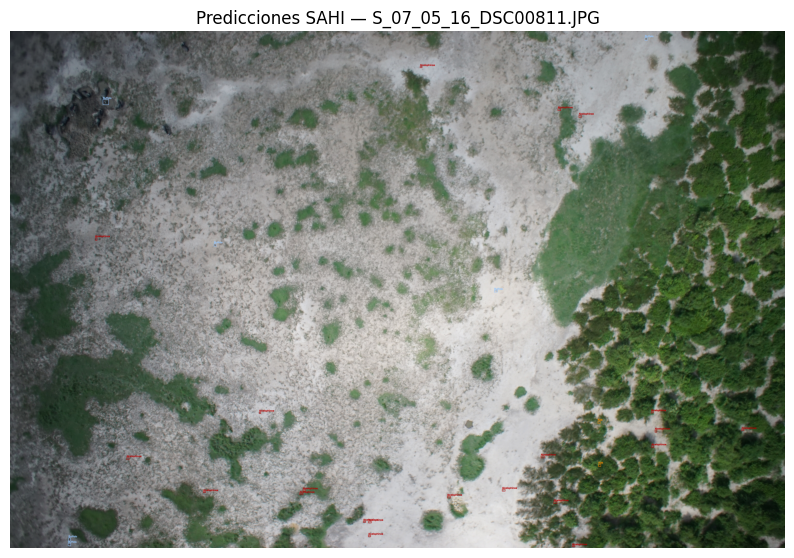

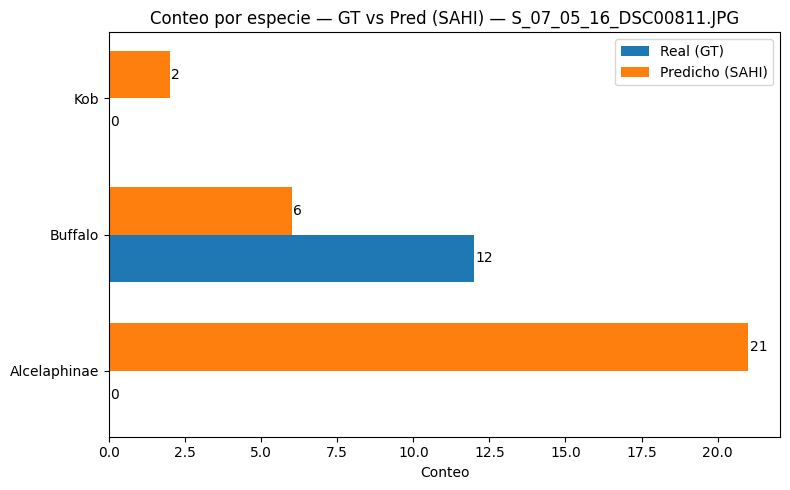


🎯 Exactitud global de conteo (SAHI): 0.00%

✔️ Conteo total PREDICCIONES (SAHI): {'Alcelaphinae': 21, 'Buffalo': 6, 'Kob': 2}
✔️ Conteo total GT: {'Buffalo': 12}


In [ ]:
# ===================================================================
# 🦁 INFERENCIA SOBRE IMAGEN BIG CON SAHI — PRED vs REAL y EXACTITUD
# ===================================================================

import cv2
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec  # ya no usamos subframes, pero lo dejamos por si
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.models.detection.rpn import RPNHead

# SAHI
from sahi.models.torchvision import TorchVisionDetectionModel
from sahi.predict import get_sliced_prediction

# ------------------------------------------------------------
# 0. CONFIGURACIÓN GLOBAL
# ------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("🔥 Using device:", DEVICE)

# Rutas en tu Drive
BEST_WEIGHTS = "/content/drive/MyDrive/general_dataset/models_v2/best_f1_macro.pth"
THR_JSON_OUT = "/content/drive/MyDrive/general_dataset/models_v2/best_thresholds_by_class.json"
GT_JSON_BIG  = "/content/drive/MyDrive/general_dataset/groundtruth/json/big_size/test_big_size_A_B_E_K_WH_WB.json"

# Clases (A/B/E/K/WH/WB)
id2name = {
    1: "Alcelaphinae",
    2: "Buffalo",
    3: "Kob",
    4: "Warthog",
    5: "Waterbuck",
    6: "Elephant"
}
num_classes = len(id2name) + 1   # +1 fondo


# ============================================================
# 1. MODELO IGUAL AL DEL ENTRENAMIENTO
# ============================================================
def build_model_for_eval(num_classes):
    sizes = (
        (8, 16),      # P3
        (32, 64),     # P4
        (128, 256),   # P5
        (256, 512),   # P6
        (512, 1024)   # P7
    )
    aspect_ratios = ((0.5, 1.0, 2.0),) * 5

    model = fasterrcnn_resnet50_fpn_v2(weights=None)

    anchor_gen = AnchorGenerator(sizes=sizes, aspect_ratios=aspect_ratios)
    model.rpn.anchor_generator = anchor_gen

    num_anchors = anchor_gen.num_anchors_per_location()[0]
    out_channels = model.backbone.out_channels
    model.rpn.head = RPNHead(out_channels, num_anchors)

    in_feats = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_feats, num_classes
    )
    return model


# ============================================================
# 2. UTILIDADES BÁSICAS (SIN SUBFRAMES MANUALES)
# ============================================================
def ensure_horizontal(img):
    """Gira la imagen 90° si es vertical (solo para visual)."""
    h, w = img.shape[:2]
    if h > w:
        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
        return img, True
    return img, False


def draw_boxes(img, boxes, labels, id2name):
    COLORS = {
        "Alcelaphinae": (0, 0, 180),
        "Buffalo":      (255, 200, 150),
        "Kob":          (0, 140, 255),
        "Warthog":      (0, 165, 255),
        "Waterbuck":    (128, 0, 255),
        "Elephant":     (50, 220, 50),
    }

    out = img.copy()
    for box, lab in zip(boxes, labels):
        x1, y1, x2, y2 = box.astype(int)
        cname = id2name[int(lab)]
        col = COLORS.get(cname, (0, 255, 0))
        cv2.rectangle(out, (x1, y1), (x2, y2), col, 2)
        cv2.putText(out, cname, (x1, max(y1 - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, col, 2)
    return out


# ============================================================
# 3. GT REAL DESDE JSON DE BIG SIZE
# ============================================================
def get_gt_counts_for_image(gt_json_path, filename):
    """
    Devuelve un dict {nombre_clase: conteo} con las anotaciones
    reales de la imagen 'filename' en el JSON big_size.
    """
    with open(gt_json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    img_id = None
    for im in data["images"]:
        if im["file_name"] == filename:
            img_id = im["id"]
            break

    if img_id is None:
        print(f"⚠️ No se encontró GT para {filename} en {gt_json_path}")
        return {}

    cat_id2name = {c["id"]: c["name"] for c in data["categories"]}

    counts = {}
    for ann in data["annotations"]:
        if ann["image_id"] == img_id:
            cname = cat_id2name.get(ann["category_id"], "UNK")
            counts[cname] = counts.get(cname, 0) + 1

    return counts


# ============================================================
# 4. INFERENCIA COMPLETA SOBRE IMAGEN BIG CON SAHI
# ============================================================
@torch.no_grad()
def infer_on_big_image(path_img):
    # ---- Umbrales por clase ----
    try:
        with open(THR_JSON_OUT, "r", encoding="utf-8") as f:
            name2thr = json.load(f)  # { "Alcelaphinae": thr, ... }
        thr_by_cls = {cid: float(name2thr[id2name[cid]]) for cid in id2name}
        print("🔎 Umbrales por clase cargados.")
    except Exception as e:
        print("⚠️ No se pudieron cargar umbrales, usando 0.5. Error:", e)
        thr_by_cls = {cid: 0.5 for cid in id2name}

    # ---- Modelo ----
    print("🔄 Cargando modelo...")
    model = build_model_for_eval(num_classes).to(DEVICE)
    model.load_state_dict(torch.load(BEST_WEIGHTS, map_location=DEVICE))
    model.eval()
    print("✅ Modelo listo.")

    # Wrap para SAHI
    detection_model = TorchVisionDetectionModel(
        model=model,
        device=DEVICE,
        confidence_threshold=0.0,  # dejamos todo, filtramos con thr_by_cls
        image_size=None,
    )

    # ---- Imagen BIG ----
    big_bgr = cv2.imread(path_img)
    if big_bgr is None:
        raise FileNotFoundError("❌ No se pudo leer la imagen.")

    fname = os.path.basename(path_img)

    big_bgr, rotated = ensure_horizontal(big_bgr)
    if rotated:
        print("↩️ Imagen vertical, rotada a horizontal.")

    big_rgb = cv2.cvtColor(big_bgr, cv2.COLOR_BGR2RGB)

    # ---- Inferencia SAHI (slicing interno) ----
    print("🧩 Ejecutando SAHI sobre la imagen grande...")
    result = get_sliced_prediction(
        image=big_rgb,
        detection_model=detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.20,
        overlap_width_ratio=0.20,
        perform_standard_pred=False  # solo slicing, sin pred directa
    )

    # ---- Filtrar predicciones según umbral por clase ----
    total_counts = {}
    boxes_list = []
    labels_list = []

    for obj in result.object_prediction_list:
        lab = int(obj.category.id)  # label del modelo (1..6)
        score = float(obj.score.value)
        thr = thr_by_cls.get(lab, 0.5)
        if score < thr:
            continue

        x1, y1, x2, y2 = obj.bbox.to_xyxy()
        boxes_list.append([x1, y1, x2, y2])
        labels_list.append(lab)

        cname = id2name[lab]
        total_counts[cname] = total_counts.get(cname, 0) + 1

    boxes_arr = np.array(boxes_list) if boxes_list else np.zeros((0, 4), dtype=np.float32)
    labels_arr = np.array(labels_list) if labels_list else np.zeros((0,), dtype=np.int64)

    # ---- Visualización big con cajas ----
    big_with_boxes = draw_boxes(big_bgr, boxes_arr, labels_arr, id2name)

    plt.figure(figsize=(10, 7))
    plt.imshow(cv2.cvtColor(big_with_boxes, cv2.COLOR_BGR2RGB))
    plt.title(f"Predicciones SAHI — {fname}")
    plt.axis("off")
    plt.show()

    # -------- GT REAL --------
    gt_counts = get_gt_counts_for_image(GT_JSON_BIG, fname)

    # -------- Gráfica combinada PRED vs GT + exactitud --------
    if gt_counts:
        all_species = sorted(set(list(gt_counts.keys()) + list(total_counts.keys())))

        gt_vals   = [gt_counts.get(sp, 0) for sp in all_species]
        pred_vals = [total_counts.get(sp, 0) for sp in all_species]

        y = np.arange(len(all_species))
        height = 0.35

        plt.figure(figsize=(8, 5))
        plt.barh(y - height/2, gt_vals, height, label="Real (GT)")
        plt.barh(y + height/2, pred_vals, height, label="Predicho (SAHI)")

        plt.yticks(y, all_species)
        plt.xlabel("Conteo")
        plt.title(f"Conteo por especie — GT vs Pred (SAHI) — {fname}")
        plt.legend()

        for i, (g, p) in enumerate(zip(gt_vals, pred_vals)):
            plt.text(g + 0.05, i - height/2, str(g), va="center")
            plt.text(p + 0.05, i + height/2, str(p), va="center")

        plt.tight_layout()
        plt.show()

        sum_gt = float(sum(gt_vals))
        sum_abs_err = float(sum(abs(p - g) for p, g in zip(pred_vals, gt_vals)))
        if sum_gt > 0:
            acc = max(0.0, 1.0 - sum_abs_err / sum_gt)
            print(f"\n🎯 Exactitud global de conteo (SAHI): {acc*100:.2f}%")
        else:
            print("\n⚠️ No hay GT para calcular exactitud.")
    else:
        print("\n⚠️ No hay anotaciones GT para esta imagen en el JSON de big size.")

    # por compatibilidad con tu llamada original, devolvemos per_sub_counts vacío
    per_sub_counts = {}

    return total_counts, per_sub_counts, gt_counts


# ===================================================================
# 5. EJECUCIÓN /content/drive/MyDrive/general_dataset/test/S_07_05_16_DSC00811.JPG
# ===================================================================
path = input("Ruta de la imagen BIG: ").strip()
total_pred, sub_pred, total_gt = infer_on_big_image(path)

print("\n✔️ Conteo total PREDICCIONES (SAHI):", total_pred)
print("✔️ Conteo total GT:", total_gt)


In [ ]:
pip install sahi pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.12.0.88
    Uninstalling opencv-python-4.12.0.88:
      Successfully uninstalled opencv-python-4.12.0.88


🔥 Using device: cuda
Ruta de la imagen BIG: /content/drive/MyDrive/general_dataset/test/S_07_05_16_DSC00811.JPG
🔎 Umbrales por clase cargados.
🔄 Cargando modelo...
✅ Modelo listo.
🧩 Ejecutando SAHI sobre la imagen grande...
Performing prediction on 12 slices.


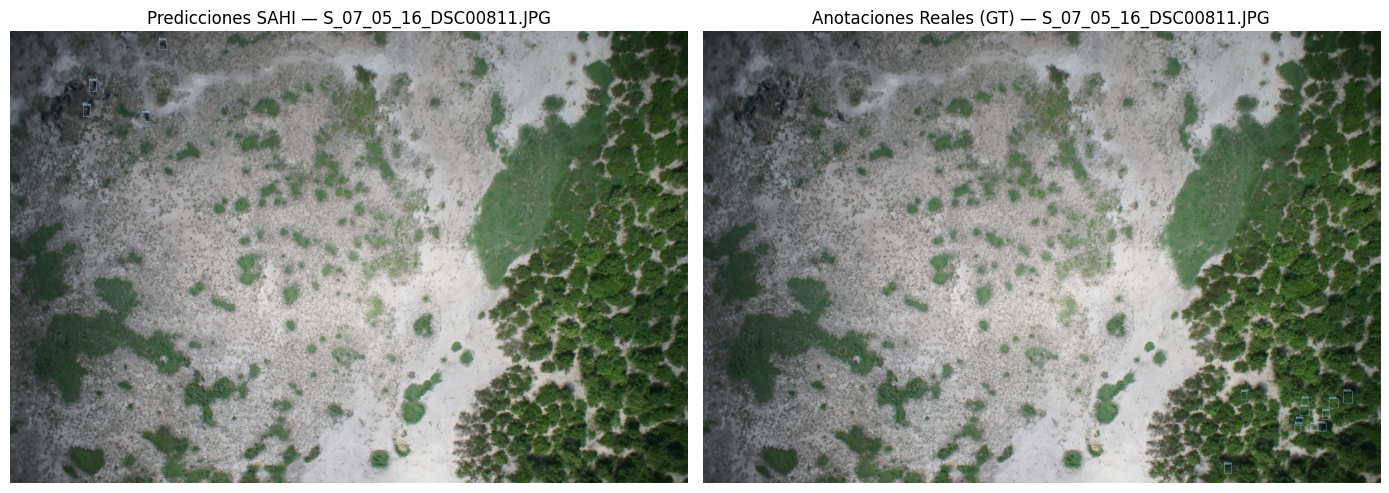

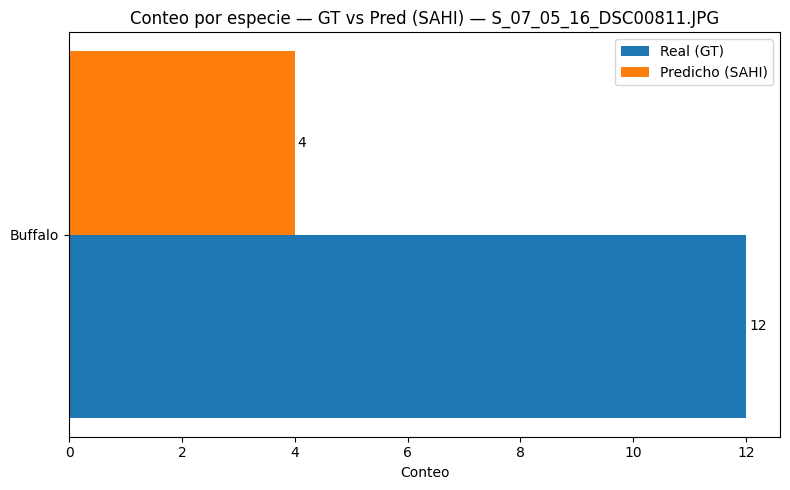


🎯 Exactitud global de conteo (SAHI): 33.33%

✔️ Conteo total PREDICCIONES (SAHI): {'Buffalo': 4}
✔️ Conteo total GT: {'Buffalo': 12}


In [ ]:
# ===================================================================
# 🦁 INFERENCIA SOBRE IMAGEN BIG CON SAHI — PRED vs REAL y EXACTITUD
# ===================================================================

import cv2
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec  # por si lo necesitas después
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.models.detection.rpn import RPNHead
from torchvision.ops import nms  # NMS global

# SAHI
from sahi.models.torchvision import TorchVisionDetectionModel
from sahi.predict import get_sliced_prediction

# ------------------------------------------------------------
# 0. CONFIGURACIÓN GLOBAL
# ------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("🔥 Using device:", DEVICE)

# Rutas en tu Drive
BEST_WEIGHTS = "/content/drive/MyDrive/general_dataset/models_v2/best_f1_macro.pth"
THR_JSON_OUT = "/content/drive/MyDrive/general_dataset/models_v2/best_thresholds_by_class.json"
GT_JSON_BIG  = "/content/drive/MyDrive/general_dataset/groundtruth/json/big_size/test_big_size_A_B_E_K_WH_WB.json"

# Clases (A/B/E/K/WH/WB)
id2name = {
    1: "Alcelaphinae",
    2: "Buffalo",
    3: "Kob",
    4: "Warthog",
    5: "Waterbuck",
    6: "Elephant"
}
num_classes = len(id2name) + 1   # +1 fondo


# ============================================================
# 1. MODELO IGUAL AL DEL ENTRENAMIENTO
# ============================================================
def build_model_for_eval(num_classes):
    sizes = (
        (8, 16),      # P3
        (32, 64),     # P4
        (128, 256),   # P5
        (256, 512),   # P6
        (512, 1024)   # P7
    )
    aspect_ratios = ((0.5, 1.0, 2.0),) * 5

    model = fasterrcnn_resnet50_fpn_v2(weights=None)

    anchor_gen = AnchorGenerator(sizes=sizes, aspect_ratios=aspect_ratios)
    model.rpn.anchor_generator = anchor_gen

    num_anchors = anchor_gen.num_anchors_per_location()[0]
    out_channels = model.backbone.out_channels
    model.rpn.head = RPNHead(out_channels, num_anchors)

    in_feats = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_feats, num_classes
    )
    return model


# ============================================================
# 2. UTILIDADES BÁSICAS
# ============================================================
def draw_boxes(img, boxes, labels, id2name):
    COLORS = {
        "Alcelaphinae": (0, 0, 180),
        "Buffalo":      (255, 200, 150),
        "Kob":          (0, 140, 255),
        "Warthog":      (0, 165, 255),
        "Waterbuck":    (128, 0, 255),
        "Elephant":     (50, 220, 50),
    }

    out = img.copy()
    for box, lab in zip(boxes, labels):
        x1, y1, x2, y2 = box.astype(int)
        cname = id2name.get(int(lab), str(lab))
        col = COLORS.get(cname, (0, 255, 0))
        cv2.rectangle(out, (x1, y1), (x2, y2), col, 2)
        cv2.putText(out, cname, (x1, max(y1 - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, col, 2)
    return out


# ============================================================
# 3. GT REAL DESDE JSON DE BIG SIZE (CUENTAS + CAJAS)
# ============================================================
def get_gt_counts_and_boxes_for_image(gt_json_path, filename):
    """
    Devuelve:
      - counts: dict {nombre_clase: conteo}
      - boxes:  np.array [N,4] en formato xyxy
      - labels: np.array [N] con ids de clase (1..6)
    """
    with open(gt_json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    img_id = None
    for im in data["images"]:
        if im["file_name"] == filename:
            img_id = im["id"]
            break

    if img_id is None:
        print(f"⚠️ No se encontró GT para {filename} en {gt_json_path}")
        return {}, np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.int64)

    cat_id2name = {c["id"]: c["name"] for c in data["categories"]}

    counts = {}
    boxes = []
    labels = []

    for ann in data["annotations"]:
        if ann["image_id"] == img_id:
            cat_id = ann["category_id"]
            cname = cat_id2name.get(cat_id, "UNK")
            counts[cname] = counts.get(cname, 0) + 1

            # COCO: bbox = [x, y, w, h] -> xyxy
            x, y, w, h = ann["bbox"]
            x1 = x
            y1 = y
            x2 = x + w
            y2 = y + h
            boxes.append([x1, y1, x2, y2])
            labels.append(cat_id)

    boxes_arr = np.array(boxes, dtype=np.float32) if boxes else np.zeros((0, 4), dtype=np.float32)
    labels_arr = np.array(labels, dtype=np.int64) if labels else np.zeros((0,), dtype=np.int64)

    return counts, boxes_arr, labels_arr


# ============================================================
# 4. INFERENCIA COMPLETA SOBRE IMAGEN BIG CON SAHI
# ============================================================
@torch.no_grad()
def infer_on_big_image(path_img):
    # ---- Umbrales por clase ----
    try:
        with open(THR_JSON_OUT, "r", encoding="utf-8") as f:
            name2thr = json.load(f)  # { "Alcelaphinae": thr, ... }
        thr_by_cls = {cid: float(name2thr[id2name[cid]]) for cid in id2name}
        print("🔎 Umbrales por clase cargados.")
    except Exception as e:
        print("⚠️ No se pudieron cargar umbrales, usando 0.5. Error:", e)
        thr_by_cls = {cid: 0.5 for cid in id2name}

    # ---- Modelo ----
    print("🔄 Cargando modelo...")
    model = build_model_for_eval(num_classes).to(DEVICE)
    model.load_state_dict(torch.load(BEST_WEIGHTS, map_location=DEVICE))
    model.eval()
    print("✅ Modelo listo.")

    # Wrap para SAHI (sin threshold fuerte aquí)
    detection_model = TorchVisionDetectionModel(
        model=model,
        device=DEVICE,
        confidence_threshold=0.0,
        image_size=None,
    )

    # ---- Imagen BIG ----
    big_bgr = cv2.imread(path_img)
    if big_bgr is None:
        raise FileNotFoundError("❌ No se pudo leer la imagen.")

    fname = os.path.basename(path_img)
    big_rgb = cv2.cvtColor(big_bgr, cv2.COLOR_BGR2RGB)

    # ---- Inferencia SAHI (slicing interno) ----
    print("🧩 Ejecutando SAHI sobre la imagen grande...")
    result = get_sliced_prediction(
        image=big_rgb,
        detection_model=detection_model,
        slice_height=2000,
        slice_width=2000,
        overlap_height_ratio=0.10,
        overlap_width_ratio=0.10,
        perform_standard_pred=False,
        postprocess_type="NMS",
        postprocess_match_threshold=0.4
    )


    # ---- Filtrar predicciones según umbral por clase + min global ----
    MIN_SCORE_GLOBAL = 0.6   # endurece los FPs
    total_counts = {}
    boxes_list = []
    labels_list = []
    scores_list = []

    for obj in result.object_prediction_list:
        lab = int(obj.category.id)   # label del modelo (1..6)
        score = float(obj.score.value)
        thr_class = thr_by_cls.get(lab, 0.5)
        thr_eff = max(thr_class, MIN_SCORE_GLOBAL)
        if score < thr_eff:
            continue

        x1, y1, x2, y2 = obj.bbox.to_xyxy()
        boxes_list.append([x1, y1, x2, y2])
        labels_list.append(lab)
        scores_list.append(score)

        cname = id2name[lab]
        total_counts[cname] = total_counts.get(cname, 0) + 1

    boxes_arr  = np.array(boxes_list, dtype=np.float32) if boxes_list else np.zeros((0, 4), dtype=np.float32)
    labels_arr = np.array(labels_list, dtype=np.int64)  if labels_list else np.zeros((0,), dtype=np.int64)
    scores_arr = np.array(scores_list, dtype=np.float32) if scores_list else np.zeros((0,), dtype=np.float32)

    # ---- NMS GLOBAL FINAL PARA LIMPIAR DUPLICADOS ----
    if len(boxes_arr) > 0:
        iou_nms_final = 0.5  # puedes probar 0.4 si aún ves duplicados
        keep = nms(
            torch.tensor(boxes_arr, dtype=torch.float32),
            torch.tensor(scores_arr, dtype=torch.float32),
            iou_nms_final
        ).numpy()
        boxes_arr  = boxes_arr[keep]
        labels_arr = labels_arr[keep]
        scores_arr = scores_arr[keep]

    # -------- GT REAL (conteos + cajas) --------
    gt_counts, gt_boxes_arr, gt_labels_arr = get_gt_counts_and_boxes_for_image(GT_JSON_BIG, fname)

    # Recalcular total_counts después de NMS (por si se eliminaron cajas)
    total_counts = {}
    for lab in labels_arr:
        cname = id2name[int(lab)]
        total_counts[cname] = total_counts.get(cname, 0) + 1

    # -------- Visual: PRED vs GT (dos imágenes) --------
    big_pred = draw_boxes(big_bgr, boxes_arr, labels_arr, id2name)
    big_gt   = draw_boxes(big_bgr, gt_boxes_arr, gt_labels_arr, id2name)

    plt.figure(figsize=(14, 7))
    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(cv2.cvtColor(big_pred, cv2.COLOR_BGR2RGB))
    ax1.set_title(f"Predicciones SAHI — {fname}")
    ax1.axis("off")

    ax2 = plt.subplot(1, 2, 2)
    ax2.imshow(cv2.cvtColor(big_gt, cv2.COLOR_BGR2RGB))
    ax2.set_title(f"Anotaciones Reales (GT) — {fname}")
    ax2.axis("off")

    plt.tight_layout()
    plt.show()

    # -------- Gráfica combinada PRED vs GT + exactitud --------
    if gt_counts:
        all_species = sorted(set(list(gt_counts.keys()) + list(total_counts.keys())))

        gt_vals   = [gt_counts.get(sp, 0) for sp in all_species]
        pred_vals = [total_counts.get(sp, 0) for sp in all_species]

        y = np.arange(len(all_species))
        height = 0.35

        plt.figure(figsize=(8, 5))
        plt.barh(y - height/2, gt_vals, height, label="Real (GT)")
        plt.barh(y + height/2, pred_vals, height, label="Predicho (SAHI)")

        plt.yticks(y, all_species)
        plt.xlabel("Conteo")
        plt.title(f"Conteo por especie — GT vs Pred (SAHI) — {fname}")
        plt.legend()

        for i, (g, p) in enumerate(zip(gt_vals, pred_vals)):
            plt.text(g + 0.05, i - height/2, str(g), va="center")
            plt.text(p + 0.05, i + height/2, str(p), va="center")

        plt.tight_layout()
        plt.show()

        sum_gt = float(sum(gt_vals))
        sum_abs_err = float(sum(abs(p - g) for p, g in zip(pred_vals, gt_vals)))
        if sum_gt > 0:
            acc = max(0.0, 1.0 - sum_abs_err / sum_gt)
            print(f"\n🎯 Exactitud global de conteo (SAHI): {acc*100:.2f}%")
        else:
            print("\n⚠️ No hay GT para calcular exactitud.")
    else:
        print("\n⚠️ No hay anotaciones GT para esta imagen en el JSON de big size.")

    # por compatibilidad con tu llamada original
    per_sub_counts = {}

    return total_counts, per_sub_counts, gt_counts


# ===================================================================
# 5. EJECUCIÓN
# ===================================================================
# Ejemplo: /content/drive/MyDrive/general_dataset/test/S_07_05_16_DSC00811.JPG
path = input("Ruta de la imagen BIG: ").strip()
total_pred, sub_pred, total_gt = infer_on_big_image(path)

print("\n✔️ Conteo total PREDICCIONES (SAHI):", total_pred)
print("✔️ Conteo total GT:", total_gt)
